In [17]:
import torch
print(torch.__version__)


2.8.0+cu126


In [18]:
# if this is the first time running, please install PyTorch Geometric
# may need to modify the version according to pytorch version
!pip install torch-scatter -f https://data.pyg.org/whl/torch-2.8.0+cu126.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-2.8.0+cu126.html
!pip install torch-cluster -f https://data.pyg.org/whl/torch-2.8.0+cu126.html
!pip install torch-spline-conv -f https://data.pyg.org/whl/torch-2.8.0+cu126.html


!pip install torch-geometric


Looking in links: https://data.pyg.org/whl/torch-2.8.0+cu126.html
Looking in links: https://data.pyg.org/whl/torch-2.8.0+cu126.html
Looking in links: https://data.pyg.org/whl/torch-2.8.0+cu126.html
Looking in links: https://data.pyg.org/whl/torch-2.8.0+cu126.html


In [19]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import StandardScaler
import torch
from torch_geometric.data import Data
from torch_geometric.utils import from_scipy_sparse_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import lil_matrix
from sklearn.decomposition import TruncatedSVD

In [20]:
# df = pd.read_excel("../data/Main_Data_Bank_new.xlsx")
# print(df.columns.tolist())
# if using google drive
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_excel("/content/drive/MyDrive/BT4222/data/Main_Data_Bank_new.xlsx")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
df = df.drop(columns=[
    'Bankkunde (1/0)', 'Mislighold 30 og 90 dg ja/nei', 'Misligholdstype',
    'SUM UTLÅN', 'SUM RAMME', 'SUM INNSKUDD', 'BANK WALLET',
    'Har lån i bank (alle banker)', 'ID NR (anonymisert dummy)',
    'Tilskudd i USD', 'Total Production Value(NOK)',
    'Subsidy Dependency Ratio', 'Bransje'
])
print(df.columns.tolist())

# Remove spaces and special characters from column names
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace(r"[^0-9A-Za-z_]", "", regex=True)
)

# Replace “ja/nei” with 1/0
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].replace({
            'ja': 1, 'nei': 0,
            'Ja': 1, 'Nei': 0,
            'JA': 1, 'NEI': 0,
            '#DIV/0!': 0
        })

# Convert the potential target column to numeric values
target_col = 'NY_tilskuddskategori'
df = df.dropna(subset=[target_col])  # Remove rows with missing values

le = LabelEncoder()
df[target_col] = le.fit_transform(df[target_col])  # Overwrite the original column



['Kommune', 'Fylke', 'NY tilskuddskategori', 'PRODUKSJON', 'Kompleks produksjon (1/0)', 'NY KOMMUNESCORE', 'NY KOMMUNESKÅRE FRITID', 'Andre dyr', 'Annet fjørfe', 'Bær', 'Bier', 'Blomster', 'Drivhus', 'Drivhus kg', 'Egg', 'Frukt', 'Geit', 'Geitemelk', 'Gress', 'Gris', 'Griseavl', 'Grønt', 'Hest', 'Korn', 'Kylling', 'Melk', 'Pels', 'Potet', 'Salg av fõr', 'Sau', 'Storfe', 'Økologisk', 'Annet', 'Ingen', 'Produkiv skog', 'Annet fjørfe dyr', 'Bær dekar', 'Egg verpehøns', 'Frukt dekar', 'Geit dyr', 'Gress dekar', 'Gris dyr', 'Grønt dekar', 'Hest dyr', 'Korn dekar', 'Kylling dyr', 'Melk dyr', 'Potet dekar', 'Sau dyr', 'Storfe dyr', 'ENG ja/nei', 'INNSKUDD ja/nei', 'BANK WALLET I MNOK', 'Kundelønnsomhet Lønnsomhet Bankr i Norge', 'Location-Leverage Mismatch Score', 'Loan-to-Production-Value Ratio', 'Production Concentration Index', 'Subsidy_Zone']


/tmp/ipython-input-3021329074.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({


In [22]:
def generate_embeddings(df, prod_col='PRODUKSJON', region_cols=['Kommune', 'Fylke'],
                        prod_dim=16, region_dim=16):
    df = df.copy()

    # --- 1. Multi-label encoding + SVD compression for PRODUKSJON ---
    df[prod_col + '_list'] = df[prod_col].fillna("").apply(lambda x: [s.strip() for s in x.split(",") if s])
    mlb = MultiLabelBinarizer()
    prod_encoded = pd.DataFrame(
        mlb.fit_transform(df[prod_col + '_list']),
        columns=mlb.classes_,
        index=df.index
    )

    # Apply SVD for dimensionality reduction
    prod_svd = TruncatedSVD(n_components=prod_dim, random_state=42)
    prod_emb = prod_svd.fit_transform(prod_encoded)
    prod_emb_df = pd.DataFrame(
        prod_emb,
        columns=[f'PROD_emb_{i}' for i in range(prod_dim)],
        index=df.index
    )

    # Merge back into df
    df = pd.concat([df, prod_emb_df], axis=1)
    df = df.drop(columns=[prod_col, prod_col + '_list'])

    # --- 2. One-hot encoding + SVD compression for region columns ---
    df_region = pd.get_dummies(df[region_cols], drop_first=True)

    region_svd = TruncatedSVD(n_components=region_dim, random_state=42)
    region_emb = region_svd.fit_transform(df_region)
    region_emb_df = pd.DataFrame(
        region_emb,
        columns=[f'REGION_emb_{i}' for i in range(region_dim)],
        index=df.index
    )

    # Merge back into df
    df = pd.concat([df, region_emb_df], axis=1)
    df = df.drop(columns=region_cols)

    return df


In [23]:
region_cols = ['Kommune', 'Fylke']
df = generate_embeddings(df, prod_col='PRODUKSJON', region_cols=region_cols,
                         prod_dim=16, region_dim=16)

print(df.columns.tolist())
print(f"target feature '{target_col}'：")
print(df[target_col].value_counts())

['NY_tilskuddskategori', 'Kompleks_produksjon_10', 'NY_KOMMUNESCORE', 'NY_KOMMUNESKRE_FRITID', 'Andre_dyr', 'Annet_fjrfe', 'Br', 'Bier', 'Blomster', 'Drivhus', 'Drivhus_kg', 'Egg', 'Frukt', 'Geit', 'Geitemelk', 'Gress', 'Gris', 'Griseavl', 'Grnt', 'Hest', 'Korn', 'Kylling', 'Melk', 'Pels', 'Potet', 'Salg_av_fr', 'Sau', 'Storfe', 'kologisk', 'Annet', 'Ingen', 'Produkiv_skog', 'Annet_fjrfe_dyr', 'Br_dekar', 'Egg_verpehns', 'Frukt_dekar', 'Geit_dyr', 'Gress_dekar', 'Gris_dyr', 'Grnt_dekar', 'Hest_dyr', 'Korn_dekar', 'Kylling_dyr', 'Melk_dyr', 'Potet_dekar', 'Sau_dyr', 'Storfe_dyr', 'ENG_janei', 'INNSKUDD_janei', 'BANK_WALLET_I_MNOK', 'Kundelnnsomhet_Lnnsomhet_Bankr_i_Norge', 'LocationLeverage_Mismatch_Score', 'LoantoProductionValue_Ratio', 'Production_Concentration_Index', 'Subsidy_Zone', 'PROD_emb_0', 'PROD_emb_1', 'PROD_emb_2', 'PROD_emb_3', 'PROD_emb_4', 'PROD_emb_5', 'PROD_emb_6', 'PROD_emb_7', 'PROD_emb_8', 'PROD_emb_9', 'PROD_emb_10', 'PROD_emb_11', 'PROD_emb_12', 'PROD_emb_13', 'PR

In [24]:
# agri_features = [
# 'Geit_dyr', 'Gress_dekar', 'Korn_dekar', 'Melk_dyr', 'Sau_dyr', 'Storfe_dyr']

# we are choosing features to construct the graph, we try to select some important agri features)
# gnn_features = ['Kompleks_produksjon_10', 'NY_KOMMUNESCORE', 'NY_KOMMUNESKRE_FRITID', 'Andre_dyr', 'Annet_fjrfe', 'Br', 'Bier', 'Blomster', 'Drivhus', 'Drivhus_kg', 'Egg', 'Frukt', 'Geit', 'Geitemelk', 'Gress', 'Gris', 'Griseavl', 'Grnt', 'Hest', 'Korn', 'Kylling', 'Melk', 'Pels', 'Potet', 'Salg_av_fr', 'Sau', 'Storfe', 'kologisk', 'Annet', 'Ingen', 'Produkiv_skog', 'Annet_fjrfe_dyr', 'Br_dekar', 'Egg_verpehns', 'Frukt_dekar', 'Geit_dyr', 'Gress_dekar', 'Gris_dyr', 'Grnt_dekar', 'Hest_dyr', 'Korn_dekar', 'Kylling_dyr', 'Melk_dyr', 'Potet_dekar', 'Sau_dyr', 'Storfe_dyr', 'ENG_janei', 'INNSKUDD_janei', 'BANK_WALLET_I_MNOK', 'Kundelnnsomhet_Lnnsomhet_Bankr_i_Norge', 'LocationLeverage_Mismatch_Score', 'LoantoProductionValue_Ratio', 'Production_Concentration_Index', 'PROD_emb_0', 'PROD_emb_1', 'PROD_emb_2', 'PROD_emb_3', 'PROD_emb_4', 'PROD_emb_5', 'PROD_emb_6', 'PROD_emb_7', 'PROD_emb_8', 'PROD_emb_9', 'PROD_emb_10', 'PROD_emb_11', 'PROD_emb_12', 'PROD_emb_13', 'PROD_emb_14', 'PROD_emb_15', 'REGION_emb_0', 'REGION_emb_1', 'REGION_emb_2', 'REGION_emb_3', 'REGION_emb_4', 'REGION_emb_5', 'REGION_emb_6', 'REGION_emb_7', 'REGION_emb_8', 'REGION_emb_9', 'REGION_emb_10', 'REGION_emb_11', 'REGION_emb_12', 'REGION_emb_13', 'REGION_emb_14', 'REGION_emb_15']
gnn_features = ['Andre_dyr', 'Annet_fjrfe', 'Br', 'Bier', 'Blomster', 'Drivhus', 'Drivhus_kg', 'Egg', 'Frukt', 'Geit', 'Geitemelk', 'Gress', 'Gris', 'Griseavl', 'Grnt', 'Hest', 'Korn', 'Kylling', 'Melk', 'Pels', 'Potet', 'Salg_av_fr', 'Sau', 'Storfe', 'kologisk', 'Annet', 'Ingen', 'Produkiv_skog', 'Annet_fjrfe_dyr', 'Br_dekar', 'Egg_verpehns', 'Frukt_dekar', 'Geit_dyr', 'Gress_dekar', 'Gris_dyr', 'Grnt_dekar', 'Hest_dyr', 'Korn_dekar', 'Kylling_dyr', 'Melk_dyr', 'Potet_dekar', 'Sau_dyr', 'Storfe_dyr']
df = df.dropna(subset=gnn_features + [target_col])
X_graph = df[gnn_features].values
y = df[target_col].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_graph)
# important features and their weights
important_features = {
    'Korn_dekar': 3.0,   # 权重系数，可根据 CatBoost importance 调整
    'Gress_dekar': 2.5,
    'Sau_dyr': 2.0,
    'Storfe_dyr': 1.8,
    'Melk_dyr': 1.5
}
for feat, w in important_features.items():
    if feat in gnn_features:
        idx = gnn_features.index(feat)
        X_scaled[:, idx] *= w

In [25]:
k = 250
# if the similarity is higher than threshold, we add an edge
threshold = 0.8
nbrs = NearestNeighbors(n_neighbors=k+1, metric='cosine').fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

# calculate cosine similarities
similarities = 1 - distances
n = X_scaled.shape[0]
A = lil_matrix((n, n))

for i in range(n):
    for j, sim in zip(indices[i][1:], similarities[i][1:]):
        if sim > threshold:
            A[i, j] = 1
            A[j, i] = 1
    if A[i].nnz == 0:
        j = indices[i][1]
        A[i, j] = 1
        A[j, i] = 1

In [26]:
degrees = np.array(A.sum(axis=1)).flatten()

print("Degree of each node:", degrees)
print("Average degree:", degrees.mean())
print("Standard deviation of degree:", degrees.std())
print("Median degree:", np.median(degrees))
print("Minimum degree:", degrees.min())
print("Maximum degree:", degrees.max())

Degree of each node: [428. 393. 334. ... 264. 425. 375.]
Average degree: 278.2889104795833
Standard deviation of degree: 98.48728491302693
Median degree: 288.0
Minimum degree: 1.0
Maximum degree: 567.0


In [27]:
edge_index, edge_attr = from_scipy_sparse_matrix(A)

data = Data(
    x=torch.tensor(X_scaled, dtype=torch.float),
    edge_index=edge_index,
    y=torch.tensor(y, dtype=torch.float)
)


In [28]:
print(data)
print(f"nodes：{data.num_nodes}")
print(f"edge：{data.num_edges}")

Data(x=[37053, 43], edge_index=[2, 10311439], y=[37053])
nodes：37053
edge：10311439


In [29]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class GraphSAGEModel(nn.Module):
    def __init__(self, in_channels, hidden, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden)
        self.conv2 = SAGEConv(hidden, out_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        return x

model = GraphSAGEModel(in_channels=X_graph.shape[1], hidden=256, out_channels=4)

In [30]:
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
edge_index_tensor = torch.tensor(edge_index, dtype=torch.long)  # [2, num_edges]
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
model.train()

epochs = 50
for epoch in range(epochs):
    optimizer.zero_grad()
    out = model(X_tensor, edge_index_tensor)

    row, col = edge_index_tensor
    loss = ((out[row] - out[col])**2).sum() / row.size(0)

    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss={loss.item():.4f}")

model.eval()
with torch.no_grad():
    embeddings = model(X_tensor, edge_index_tensor).numpy()
for i in range(embeddings.shape[1]):
    df[f"gnn_emb_{i}"] = embeddings[:, i]

/tmp/ipython-input-1620156440.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  edge_index_tensor = torch.tensor(edge_index, dtype=torch.long)  # [2, num_edges]


Epoch 0, Loss=0.0892
Epoch 10, Loss=0.0270
Epoch 20, Loss=0.0048
Epoch 30, Loss=0.0022
Epoch 40, Loss=0.0011


--- 1. Preparing data ---
Initial feature matrix shape: (37053, 49)
Target vector shape: (37053,)

--- 1. Checking for duplicate column names ---
No duplicate column names found.

--- 2. Splitting dataset ---
Training set shape: (33347, 49)
Testing set shape: (3706, 49)

--- 3. Initializing and training CatBoost model ---
0:	learn: 1.3584365	test: 1.3587121	best: 1.3587121 (0)	total: 45.2ms	remaining: 1m 30s
100:	learn: 0.5950850	test: 0.6117058	best: 0.6117058 (100)	total: 4.37s	remaining: 1m 22s
200:	learn: 0.4957329	test: 0.5200165	best: 0.5200165 (200)	total: 8.49s	remaining: 1m 15s
300:	learn: 0.4548569	test: 0.4864976	best: 0.4864976 (300)	total: 12.7s	remaining: 1m 11s
400:	learn: 0.4291149	test: 0.4675283	best: 0.4675283 (400)	total: 17s	remaining: 1m 7s
500:	learn: 0.4082926	test: 0.4528151	best: 0.4528151 (500)	total: 21.1s	remaining: 1m 3s
600:	learn: 0.3912163	test: 0.4405778	best: 0.4405778 (600)	total: 25.1s	remaining: 58.5s
700:	learn: 0.3765055	test: 0.4310178	best: 0.4

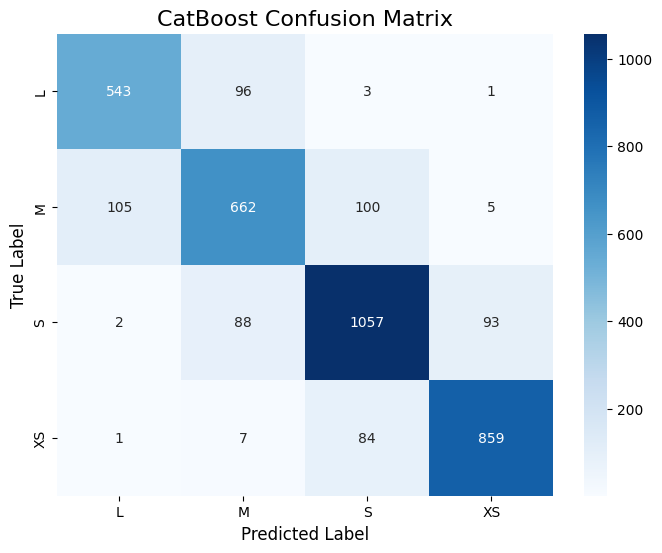


--- 5. Feature Importance Analysis ---
Top 20 Most Important Features:
                        Feature Id  Importances
0   Production_Concentration_Index     9.192455
1                       Korn_dekar     9.128355
2                        gnn_emb_1     8.062540
3                       PROD_emb_0     7.351039
4                        gnn_emb_2     7.192816
5                        gnn_emb_0     6.760580
6           Kompleks_produksjon_10     6.404950
7                        gnn_emb_3     6.269252
8                       PROD_emb_5     3.956962
9                       PROD_emb_2     3.925862
10                      PROD_emb_3     3.728766
11                      PROD_emb_1     2.705683
12                      PROD_emb_6     2.636823
13              BANK_WALLET_I_MNOK     1.695815
14                    Subsidy_Zone     1.678973
15                     PROD_emb_12     1.599681
16                      PROD_emb_7     1.562134
17                      PROD_emb_8     1.343846
18              

/tmp/ipython-input-1465942273.py:139: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


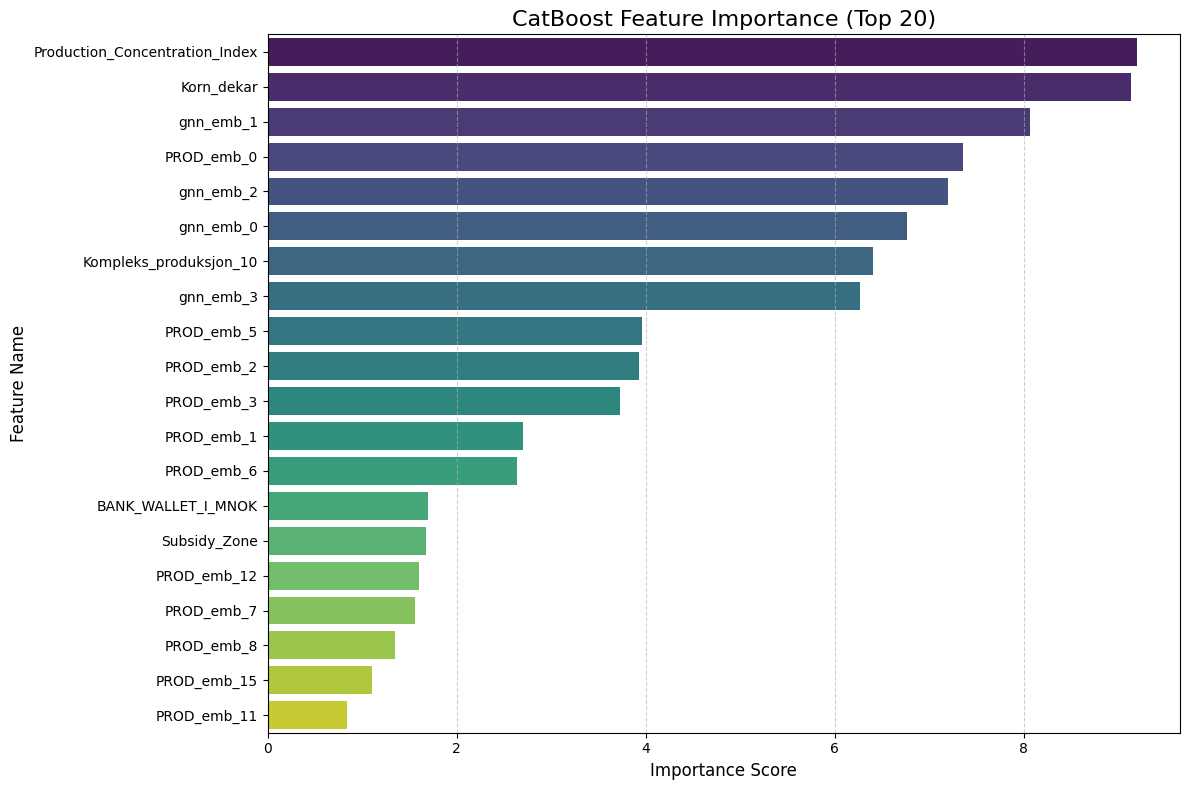

In [31]:
# If CatBoost or Seaborn are not installed, uncomment the following line:
!pip install catboost seaborn

import pandas as pd
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, roc_auc_score, confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Prepare the final dataset ---
# The dataframe `df` already contains both the original features and the GNN-generated embeddings.
# We will use this enhanced dataframe for training.

print("--- 1. Preparing data ---")
target_col = 'NY_tilskuddskategori'
# becase want to see the impact of gnn embeddings, we drop the agricultural features
X_final = df.drop(columns=[
    target_col, 'Andre_dyr', 'Annet_fjrfe', 'Br', 'Bier', 'Blomster', 'Drivhus', 'Drivhus_kg', 'Egg', 'Frukt', 'Geit', 'Geitemelk', 'Gress', 'Gris', 'Griseavl', 'Grnt', 'Hest', 'Korn', 'Kylling', 'Melk', 'Pels', 'Potet', 'Salg_av_fr', 'Sau', 'Storfe', 'kologisk', 'Annet', 'Ingen', 'Produkiv_skog', 'Annet_fjrfe_dyr', 'Br_dekar', 'Egg_verpehns', 'Frukt_dekar', 'Geit_dyr', 'Gress_dekar', 'Gris_dyr', 'Grnt_dekar', 'Hest_dyr', 'Melk_dyr', 'Potet_dekar', 'Sau_dyr', 'Storfe_dyr'
])
# X_final = df.drop(columns=[target_col])
y_final = df[target_col]

print(f"Initial feature matrix shape: {X_final.shape}")
print(f"Target vector shape: {y_final.shape}\n")

cols = pd.Series(X_final.columns)

if cols.duplicated().any():
    print("Duplicate column names detected. Renaming...")
    duplicates = cols[cols.duplicated()].unique()
    print(f"Duplicated columns: {list(duplicates)}")

    # Rename duplicates by appending incremental suffixes
    col_counts = {}
    new_columns = []

    for col in X_final.columns:
        if col in col_counts:
            col_counts[col] += 1
            new_columns.append(f"{col}_{col_counts[col]}")
        else:
            col_counts[col] = 0
            new_columns.append(col)

    X_final.columns = new_columns
    print("Column renaming completed.\n")
else:
    print("No duplicate column names found.\n")


# --- 2. Train-test split ---
print("--- 2. Splitting dataset ---")
# Use stratified sampling to preserve class distribution across train/test splits.
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.1, random_state=42, stratify=y_final
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}\n")


# --- 3. Initialize and train CatBoost model ---
print("--- 3. Initializing and training CatBoost model ---")

model_cb = CatBoostClassifier(
    iterations=2000,           # Number of trees
    learning_rate=0.02,        # Learning rate
    depth=8,                   # Maximum tree depth
    loss_function='MultiClass', # Multi-class loss
    eval_metric='MultiClass',   # Evaluation metric
    random_seed=42,             # Random seed for reproducibility
    verbose=100                 # Log training every 100 iterations
)

# Fit the model with early stopping to avoid overfitting
model_cb.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=200  # Stop if no improvement for 200 rounds
)


# --- 4. Evaluate model performance on the test set ---
print("\n--- 4. Evaluating model performance ---")

y_pred = model_cb.predict(X_test)
y_pred_proba = model_cb.predict_proba(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

# Multi-class ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
print(f"Model ROC AUC Score: {roc_auc:.4f}\n")

# Classification report
class_names = le.classes_  # Original class labels from label encoder
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=[str(c) for c in class_names]))

# Confusion matrix
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=[str(c) for c in class_names],
    yticklabels=[str(c) for c in class_names]
)
plt.title('CatBoost Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()


# --- 5. Feature importance analysis ---
print("\n--- 5. Feature Importance Analysis ---")

feature_importance = model_cb.get_feature_importance(prettified=True)

print("Top 20 Most Important Features:")
print(feature_importance.head(20))

# Visualize feature importance
plt.figure(figsize=(12, 8))
sns.barplot(
    x="Importances", y="Feature Id",
    data=feature_importance.head(20),
    palette="viridis"
)
plt.title('CatBoost Feature Importance (Top 20)', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
